In [1]:
import torchmetrics
import torchvision
import torch
import torch.nn as nn
from sympy.codegen.ast import float32

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [3]:
import urllib.request
import zipfile

url = "https://download.pytorch.org/tutorial/hymenoptera_data.zip"
urllib.request.urlretrieve(url, "hymenoptera_data.zip")

with zipfile.ZipFile("hymenoptera_data.zip", "r") as z:
    z.extractall(".")

In [4]:
from torchvision import models

weights = models.ResNet50_Weights.DEFAULT
model = models.resnet50(weights=weights).to(device)

In [5]:
first_conv = next(m for _, m in model.named_modules() if isinstance(m, nn.Conv2d))

In [6]:
print(first_conv)

Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)


In [7]:
print(weights.transforms())

ImageClassification(
    crop_size=[224]
    resize_size=[232]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)


In [8]:
import torchvision.transforms.v2 as T


transforms = T.Compose([
    T.RandomHorizontalFlip(p=0.5),
    T.RandomVerticalFlip(p=0.5),
    T.RandomResizedCrop(size=(224, 224)),
    T.RandomRotation(degrees=30),
    T.ToImage(),
    T.ToDtype(dtype=torch.float32, scale=True),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [9]:
from torchvision.datasets import ImageFolder

train_aug    = ImageFolder("hymenoptera_data/train", transform=transforms)
train_no_aug = ImageFolder("hymenoptera_data/train", transform=weights.transforms())
test_data    = ImageFolder("hymenoptera_data/val",   transform=weights.transforms())

In [10]:
import random

indices = list(range(len(train_aug)))
random.shuffle(indices)
split = int(0.8 * len(indices))

In [11]:
from torch.utils.data import Subset

train_data = Subset(train_aug,    indices[:split])
valid_data = Subset(train_no_aug, indices[split:])

In [12]:
print(len(train_data))
print(len(valid_data))
print(len(test_data))

195
49
153


In [13]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_data, batch_size=32, num_workers=4, pin_memory=True, shuffle=True)
valid_loader = DataLoader(valid_data, batch_size=32, num_workers=4, pin_memory=True)
test_loader = DataLoader(test_data, batch_size=32, num_workers=4, pin_memory=True)

In [14]:
[name for name, child in model.named_children()]

['conv1',
 'bn1',
 'relu',
 'maxpool',
 'layer1',
 'layer2',
 'layer3',
 'layer4',
 'avgpool',
 'fc']

In [15]:
print(model.fc)

Linear(in_features=2048, out_features=1000, bias=True)


In [22]:
model.fc = nn.Linear(2048, 2).to(device)

In [17]:
for param in model.parameters():
    param.requires_grad=False

for param in model.fc.parameters():
    param.requires_grad=True

for param in model.layer4.parameters():
    param.requires_grad=True

In [18]:
for name, param in model.named_parameters():
    print(name, param.requires_grad)

conv1.weight False
bn1.weight False
bn1.bias False
layer1.0.conv1.weight False
layer1.0.bn1.weight False
layer1.0.bn1.bias False
layer1.0.conv2.weight False
layer1.0.bn2.weight False
layer1.0.bn2.bias False
layer1.0.conv3.weight False
layer1.0.bn3.weight False
layer1.0.bn3.bias False
layer1.0.downsample.0.weight False
layer1.0.downsample.1.weight False
layer1.0.downsample.1.bias False
layer1.1.conv1.weight False
layer1.1.bn1.weight False
layer1.1.bn1.bias False
layer1.1.conv2.weight False
layer1.1.bn2.weight False
layer1.1.bn2.bias False
layer1.1.conv3.weight False
layer1.1.bn3.weight False
layer1.1.bn3.bias False
layer1.2.conv1.weight False
layer1.2.bn1.weight False
layer1.2.bn1.bias False
layer1.2.conv2.weight False
layer1.2.bn2.weight False
layer1.2.bn2.bias False
layer1.2.conv3.weight False
layer1.2.bn3.weight False
layer1.2.bn3.bias False
layer2.0.conv1.weight False
layer2.0.bn1.weight False
layer2.0.bn1.bias False
layer2.0.conv2.weight False
layer2.0.bn2.weight False
layer2.0.bn2

In [24]:
from utils.utils import train
import torchmetrics

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-5)
criterion = nn.CrossEntropyLoss()
metric = torchmetrics.Accuracy(task="multiclass", num_classes=2).to(device)
n_epochs = 30
train(model, optimizer, criterion, train_loader, valid_loader, metric, n_epochs, n_iter_no_improvements=10)

Epoch: 1/30, Loss: 0.5802, Val Score: 0.8776
Epoch: 2/30, Loss: 0.5659, Val Score: 0.8776
Epoch: 3/30, Loss: 0.5653, Val Score: 0.8776
Epoch: 4/30, Loss: 0.5402, Val Score: 0.8980
Epoch: 5/30, Loss: 0.5221, Val Score: 0.9184
Epoch: 6/30, Loss: 0.5201, Val Score: 0.9184
Epoch: 7/30, Loss: 0.5131, Val Score: 0.9184
Epoch: 8/30, Loss: 0.5258, Val Score: 0.8776
Epoch: 9/30, Loss: 0.4886, Val Score: 0.8980
Epoch: 10/30, Loss: 0.4859, Val Score: 0.9184
Epoch: 11/30, Loss: 0.4665, Val Score: 0.8980
Epoch: 12/30, Loss: 0.4740, Val Score: 0.8980
Epoch: 13/30, Loss: 0.4615, Val Score: 0.8980
Epoch: 14/30, Loss: 0.4407, Val Score: 0.8980
Epoch: 15/30, Loss: 0.4295, Val Score: 0.8980
Validation score has not improved for 10 epochs, stopping training


0.918367326259613

In [25]:
for param in model.parameters():
    param.requires_grad=True

In [31]:
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-5)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20)
train(model, optimizer, criterion, train_loader, valid_loader, metric, n_epochs=20, n_iter_no_improvements=5, scheduler=scheduler)

Epoch: 1/20, Loss: 0.2516, Val Score: 0.9184
Epoch: 2/20, Loss: 0.1456, Val Score: 0.9184
Epoch: 3/20, Loss: 0.1950, Val Score: 0.9184
Epoch: 4/20, Loss: 0.1478, Val Score: 0.8980
Epoch: 5/20, Loss: 0.1415, Val Score: 0.8980
Epoch: 6/20, Loss: 0.2948, Val Score: 0.8980
Validation score has not improved for 5 epochs, stopping training


0.918367326259613

In [34]:
from utils.utils import evaluate

evaluate(model, test_loader, metric)

0.9411764740943909

In [35]:
X_batch, y_batch = next(iter(test_loader))
print(X_batch.shape, y_batch.shape)

torch.Size([32, 3, 224, 224]) torch.Size([32])


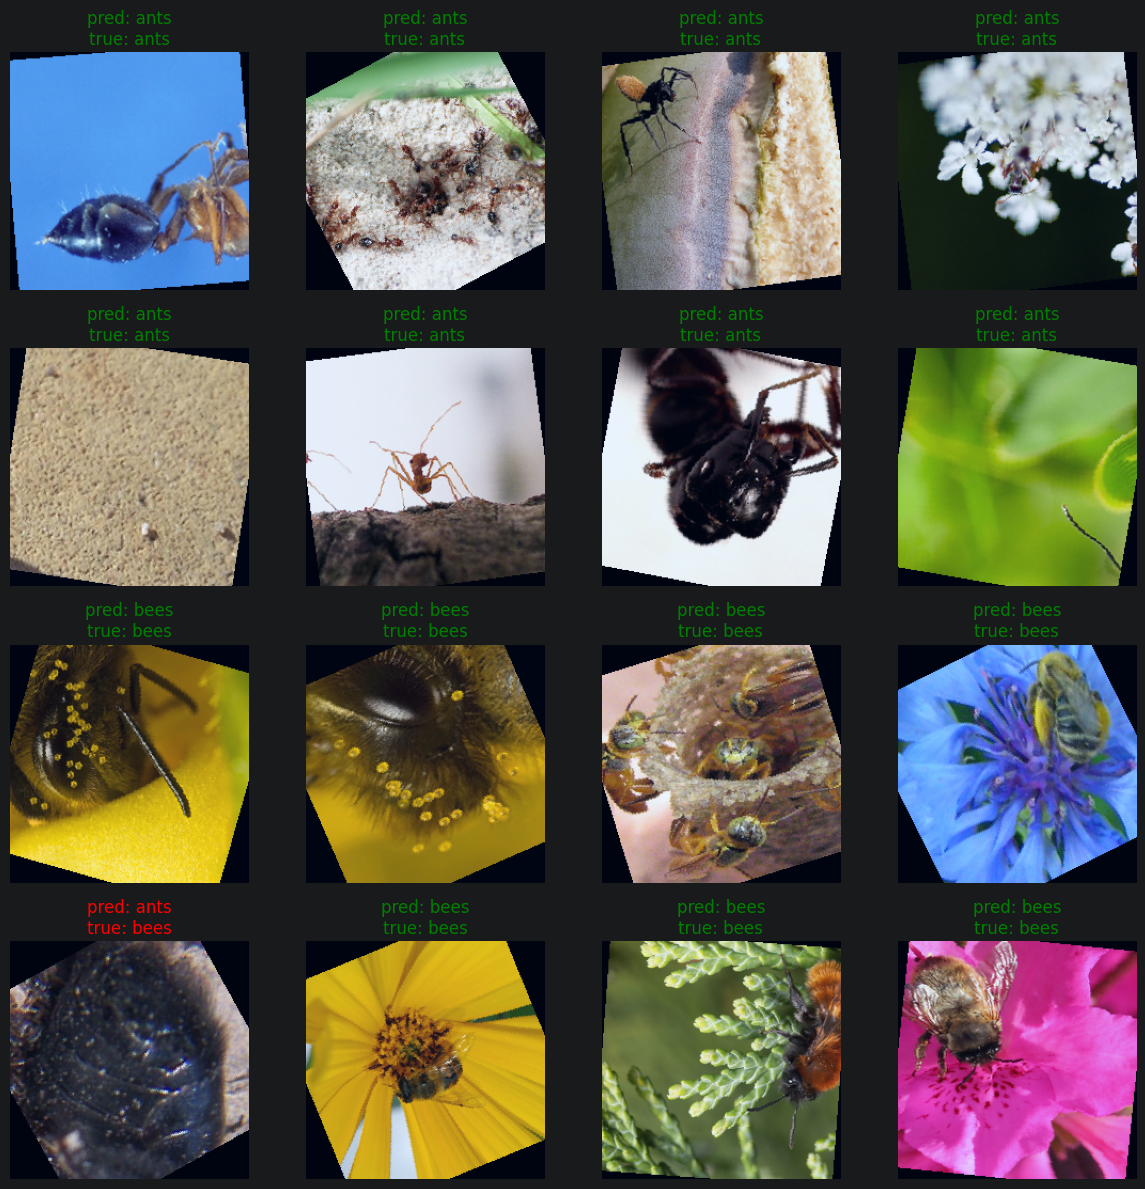

In [39]:
import matplotlib.pyplot as plt

class_names = train_aug.classes

ant_indices = [i for i, (_, y) in enumerate(train_aug) if y == 0][:8]
bee_indices = [i for i, (_, y) in enumerate(train_aug) if y == 1][:8]
sample = Subset(train_aug, ant_indices + bee_indices)
sample_loader = DataLoader(sample, batch_size=16)
model.eval()
X_batch, y_batch = next(iter(sample_loader))
X_batch = X_batch.to(device)

with torch.no_grad():
    preds = model(X_batch).argmax(dim=1).cpu()

fig, axes = plt.subplots(4, 4, figsize=(12, 12))
for i, ax in enumerate(axes.flat):
    img = X_batch[i].cpu().permute(1, 2, 0).numpy()
    img = (img - img.min()) / (img.max() - img.min())
    ax.imshow(img)
    color = 'green' if preds[i] == y_batch[i] else 'red'
    ax.set_title(f"pred: {class_names[preds[i]]}\ntrue: {class_names[y_batch[i]]}", color=color)
    ax.axis('off')

plt.tight_layout()
plt.show()

In [40]:
from torchmetrics.classification import MulticlassPrecision, MulticlassRecall, MulticlassF1Score

precision = MulticlassPrecision(num_classes=2).to(device)
recall = MulticlassRecall(num_classes=2).to(device)
f1 = MulticlassF1Score(num_classes=2).to(device)

model.eval()
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        preds = model(X_batch)
        precision.update(preds, y_batch)
        recall.update(preds, y_batch)
        f1.update(preds, y_batch)

print(f"Precision: {precision.compute()}")
print(f"Recall:    {recall.compute()}")
print(f"F1:        {f1.compute()}")

Precision: 0.9405128359794617
Recall:    0.9435455799102783
F1:        0.9410152435302734
